In [2]:
import sys
print(sys.executable)

/home/gona/miniconda3/envs/jpt-plots/bin/python


In [3]:
import os
import tarfile
import shutil
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [6]:
# ===================== CONFIG =====================
query = "q1"
failure = "/srv/nfs/flink/nexmark/scalability/"
cores_list = ["p1", "p4", "p8", "p10", "p15", "p20", "p30"]
base_dir = Path(failure + query)
#base_dir = Path.cwd()
output_dir = Path("analysis_output") / failure / query
window_seconds = 5
# ==================================================

In [7]:
output_dir.mkdir(parents=True, exist_ok=True)

print("[START] Analysis pipeline starting...")
print(f"Query: {query}")
print(f"Base dir: {base_dir}")
print(f"Output dir: {output_dir}")

run_dirs = []

for core in cores_list:
    core_path = base_dir / core
    if core_path.is_dir():
        run_dirs.append(core_path)

run_dirs = sorted(run_dirs)

print(f"[INFO] Found {len(run_dirs)} run directories")

if not run_dirs:
    print(f"No runs found for {query}")
    exit(1)

node_data = {}
throughput_summary = {}  # {node: {cores: throughput}}
cluster_throughput = {}

[START] Analysis pipeline starting...
Query: q1
Base dir: /srv/nfs/flink/nexmark/scalability/q1
Output dir: /srv/nfs/flink/nexmark/scalability/q1
[INFO] Found 7 run directories


In [8]:
# ===================== HELPERS =====================
def compute_latency_summary(df):
    return {
        "avg": df["latency_ms"].mean(),
        "p50": df["latency_ms"].quantile(0.50),
        "p95": df["latency_ms"].quantile(0.95),
        "p99": df["latency_ms"].quantile(0.99),
    }

def compute_latency(df):
    r = df["latency_ms"].resample(f"{window_seconds}s")
    return pd.DataFrame({
        "p50": r.quantile(0.5),
        "p95": r.quantile(0.95),
        "p99": r.quantile(0.99),
    })

def compute_throughput(df):
    return df["auction"].resample(f"{window_seconds}s").size()

def smooth(series, w=5):
    return series.rolling(w, min_periods=1).mean()

def detect_failures(tp):
    gaps = []
    start = None

    for ts, v in tp.items():
        if v == 0 and start is None:
            start = ts
        elif v > 0 and start is not None:
            gaps.append((start, ts))
            start = None

    return gaps

In [9]:
def parse_part_file(pf):
    rows = []
    bad = 0

    print(f"[FILE] Processing: {os.path.basename(pf)}")

    with open(pf, "r", errors="ignore") as f:
        for line_num, line in enumerate(f, 1):
            parts = line.rstrip("\n").split(",")

            if len(parts) < 6:
                bad += 1
                continue

            #auction, price, event_time, processed_time= parts

            try:
                auction = parts[0]
                bidder = parts[1]
                price = parts[2]
                event_time = parts[3].strip('"')
                processed_time = parts[4].strip('"')
                extra = parts[5]

                rows.append({
                    "auction": int(auction),
                    "bidder": int(auction),
                    "price": float(price),
                    "event_time": event_time,
                    "processed_time": processed_time,
                    "extra": extra
                })
            except:
                bad += 1

    print(f"    -> parsed rows: {len(rows)} | bad rows: {bad}")
    return pd.DataFrame(rows)

In [ ]:
for cores in cores_list:
    data_path = failure / cores

    print(f"[DATA] {cores} → {data_path}")

    if not data_path.exists():
        print(f"[WARN] Missing path")
        continue

    part_files = sorted(
        glob.glob(str(data_path / "**" / "part-*"), recursive=True)
    )

    if not part_files:
        print(f"[WARN] No part files")
        continue

    dfs = []
    for pf in part_files:
        df_part = parse_part_file(pf)
        if not df_part.empty:
            dfs.append(df_part)

    if not dfs:
        continue

    df = pd.concat(dfs, ignore_index=True)

        # ---- timestamps ----
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df["processed_time"] = pd.to_datetime(df["processed_time"], errors="coerce")

    df = df.dropna(subset=["event_time", "processed_time"])

    df["processed_time"] += pd.Timedelta(hours=4)

        # ---- latency ----
    df["latency_ms"] = (
        (df["processed_time"] - df["event_time"])
        .dt.total_seconds() * 1000
    )

    df = df.sort_values("processed_time").set_index("processed_time")

        # ---- throughput summary ----
    tp = compute_throughput(df)

        # steady-state avg (ignore first 20%)
    tp_ss = tp[int(len(tp)*0.2):]
    avg_tp = tp_ss.mean() if not tp_ss.empty else tp.mean()

    throughput_summary.setdefault({})[cores] = avg_tp

    print(f"[TP]{cores}: {avg_tp:.2f}")

# ===================== LATENCY SUMMARY =====================
print("\n================ LATENCY SUMMARY ================\n")

for node, df in node_data.items():
    stats = compute_latency_summary(df)

    print(f"[{node}]")
    print(f"  Avg latency : {stats['avg']:.2f} ms")
    print(f"  P50 latency : {stats['p50']:.2f} ms")
    print(f"  P95 latency : {stats['p95']:.2f} ms")
    print(f"  P99 latency : {stats['p99']:.2f} ms")
    print()

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [8]:
node_data

{'n0':                          auction   bidder        price  \
 processed_time                                           
 2026-04-13 03:17:32.386     1000     1000     5965.560   
 2026-04-13 03:17:32.390     1000     1000  1960927.696   
 2026-04-13 03:17:32.391     1009     1009    10596.360   
 2026-04-13 03:17:32.391     1008     1008      557.512   
 2026-04-13 03:17:32.391     1000     1000   137203.340   
 ...                          ...      ...          ...   
 2026-04-13 03:17:36.642  3017516  3017516  9344941.688   
 2026-04-13 03:17:36.642  3017538  3017538  2437089.252   
 2026-04-13 03:17:36.642  3017604  3017604    28599.276   
 2026-04-13 03:17:36.642  3017565  3017565  8362195.128   
 2026-04-13 03:17:36.642  3017600  3017600  6238247.836   
 
                                      event_time  \
 processed_time                                    
 2026-04-13 03:17:32.386 2026-04-13 03:17:28.533   
 2026-04-13 03:17:32.390 2026-04-13 03:17:28.533   
 2026-04-13 03:17

[PLOT] Latency...


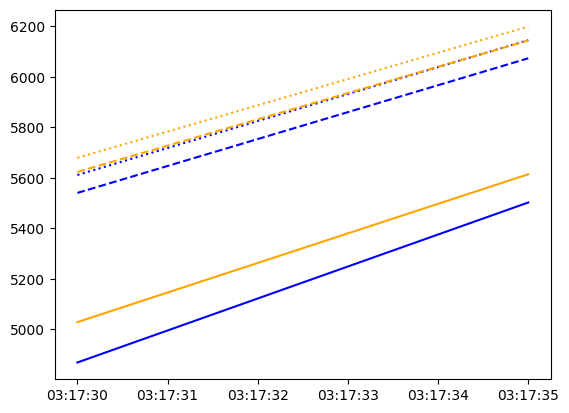

In [9]:
# ===================== PLOTTING =====================
node_colors = {"n0": "blue", "n1": "orange"}

# ---- Latency ----
print("[PLOT] Latency...")
plt.figure()

for node, df in node_data.items():
    lat = compute_latency(df)

    plt.plot(smooth(lat["p50"]), label=f"{node} p50", color=node_colors.get(node))
    plt.plot(smooth(lat["p95"]), "--", label=f"{node} p95", color=node_colors.get(node))
    plt.plot(smooth(lat["p99"]), ":", label=f"{node} p99", color=node_colors.get(node))


In [10]:
print("[PLOT] Throughput (time)...")
plt.figure()

all_failures = []

# ---- per-node + cluster aggregation ----
cluster_tp = None

for node, df in node_data.items():
    tp = compute_throughput(df)
    tp_s = smooth(tp)

    # per-node line
    plt.plot(tp_s, label=node, color=node_colors.get(node))

    # initialize cluster series
    if cluster_tp is None:
        cluster_tp = tp.copy()
    else:
        cluster_tp = cluster_tp.add(tp, fill_value=0)

    gaps = detect_failures(tp)
    for start, end in gaps:
        all_failures.append((start, end, node))

# ---- cluster throughput line ----
if cluster_tp is not None:
    cluster_tp_s = smooth(cluster_tp)
    plt.plot(cluster_tp_s, label="cluster (n0+n1)", color="black", linewidth=2)

# ---- highlight failures ----
for start, end, node in all_failures:
    plt.axvspan(start, end, alpha=0.15, color=node_colors.get(node))

plt.title(f"Throughput ({query})")
plt.xlabel("Time")
plt.ylabel("events/sec")
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend()
else:
    print("[WARN] No data plotted → skipping legend")
plt.tight_layout()
plt.savefig(output_dir / f"throughput_{query}.png")
plt.close()

[PLOT] Throughput (time)...


In [11]:
node_data

{'n0':                          auction   bidder        price  \
 processed_time                                           
 2026-04-13 03:17:32.386     1000     1000     5965.560   
 2026-04-13 03:17:32.390     1000     1000  1960927.696   
 2026-04-13 03:17:32.391     1009     1009    10596.360   
 2026-04-13 03:17:32.391     1008     1008      557.512   
 2026-04-13 03:17:32.391     1000     1000   137203.340   
 ...                          ...      ...          ...   
 2026-04-13 03:17:36.642  3017516  3017516  9344941.688   
 2026-04-13 03:17:36.642  3017538  3017538  2437089.252   
 2026-04-13 03:17:36.642  3017604  3017604    28599.276   
 2026-04-13 03:17:36.642  3017565  3017565  8362195.128   
 2026-04-13 03:17:36.642  3017600  3017600  6238247.836   
 
                                      event_time  \
 processed_time                                    
 2026-04-13 03:17:32.386 2026-04-13 03:17:28.533   
 2026-04-13 03:17:32.390 2026-04-13 03:17:28.533   
 2026-04-13 03:17

In [12]:
print("[PLOT] Throughput vs cores...")
plt.figure()

core_values = [int(c.replace("p", "")) for c in cores_list]

# ---- per-node curves ----
for node, core_map in throughput_summary.items():
    y = []
    x = []

    for c in cores_list:
        if c in core_map:
            x.append(int(c.replace("p", "")))
            y.append(core_map[c])

    if len(y) > 0:
        plt.plot(x, y, marker="o", label=node)

# ---- cluster aggregation ----
cluster_curve = []

for c in cores_list:
    total = 0
    count = 0

    for node, core_map in throughput_summary.items():
        if c in core_map:
            total += core_map[c]
            count += 1

    if count > 0:
        cluster_curve.append(total)
    else:
        cluster_curve.append(None)

# clean missing points
x_clean = []
y_clean = []

for x, y in zip(core_values, cluster_curve):
    if y is not None:
        x_clean.append(x)
        y_clean.append(y)

plt.plot(x_clean, y_clean, marker="o", linewidth=3, color="black", label="cluster (n0+n1)")

plt.title(f"Throughput vs Cores ({query})")
plt.xlabel("Number of Cores")
plt.ylabel("Events/sec")
plt.grid(True, linestyle="--", alpha=0.5)
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend()
else:
    print("[WARN] No data plotted → skipping legend")
plt.tight_layout()

plt.savefig(output_dir / f"throughput_vs_cores_{query}.png")
plt.close()

[PLOT] Throughput vs cores...
